# Fitting data

***
##  Si | Fe | SiO2 | lipids in three (Latest 26-03-15) POLREF run

In [1]:
# %pip install hogben

#### User choices:

In [2]:
# MCMC run after fittings -- True/False (takes some time for uncertainty estimation)
DO_SAMPLING = False

# Run Fisher information to optimise substrate assembly -- True/False
DO_FISHER = True

# Chosen magnetic reference layer and capping layer 
MRL = "Fe"
Capping = "SiO2"

# Save figures into `figures folder` -- True/False
SAVE_FIGS = True

#### Imports:

In [3]:
# use matplotlib for plotting
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import os.path

from hogben.models.samples import Sample
from hogben.optimise import optimise_parameters

from functions.fitting_stage_helpers import StagePlotConfig, run_fitting_stage_plots
from functions.fisher_helpers import (
    FisherContext,
    baseline_by_name,
    process_hogben_figures,
    reset_to_fitted_baseline,
    snapshot_params,
    restore_params
)

import refnx

# the analysis module contains the curvefitting engine
from refnx.analysis import CurveFitter, GlobalObjective

plt.rcParams['figure.figsize'] = (8,6)
plt.rcParams['figure.dpi'] = 100

# Set global font size
plt.rcParams.update({'font.size': 16})  # Change 16 to whatever size you prefer

#### Define all the parameters here

Anything which you might want to vary needs to be a refnx `Parameter`

In [4]:
data_path = os.path.join(os.path.abspath(os.getcwd()),'POLREF_data')
data_filenames = [
                 'Sample1_Sub_D2O_no_bkg_subtraction_d',
                 'Sample1_Sub_D2O_no_bkg_subtraction_u',
                 'Sample1_Sub_H2O_no_bkg_subtraction_d',
                 'Sample1_Sub_H2O_no_bkg_subtraction_u',
                 'Sample1_Sub_SMW_no_bkg_subtraction_d',
                 'Sample1_Sub_SMW_no_bkg_subtraction_u',
                 ]
scales = 0.8*np.ones(len(data_filenames))
bkgs = 1.5e-5*np.ones(len(data_filenames))
dq = 5  # resolution in cons. dq/q percentage

## Relevant SLD vals taken from ORSO query database

## Define known values.
si_sld = 2.074

## Define the varying parameters of the model.
si_rough                    = refnx.analysis.Parameter(3,     'Si Roughness', (2,5))

sio2_native_thick           = refnx.analysis.Parameter(35.2,   'Native SiO2 Thick.', (25,50)) # Change to 20 instead of 50
sio2_native_rough           = refnx.analysis.Parameter(2,   'Native SiO2 Rough.', (2,5)) # Fix to 2 no vary
sio2_native_sld             = refnx.analysis.Parameter(3.52,  'Native SiO2 SLD', (3,4))

# Fe magnetic reference layer
MRL_thick                    = refnx.analysis.Parameter(110.3,   'Fe Thickness', (90,115))
MRL_rough                    = refnx.analysis.Parameter(2.2,     'Fe Roughness', (2,5))
MRL_sld                      = refnx.analysis.Parameter(7.82,   'Fe nSLD', (7,8.3))  # Fe SLD 1uB = 2.28 A^-2
MRL_mag                      = refnx.analysis.Parameter(4.58,     'Fe mSLD', (4.5,5))  # Fe SLD 1uB = 2.28 A^-2

# SiO2 capping layer
cap_thick              = refnx.analysis.Parameter(1131.3,  'Cap SiO2 Thickness', (1020,1200))
cap_sld                = refnx.analysis.Parameter(3.71,  'Cap SiO2 SLD', (3,4))
cap_rough              = refnx.analysis.Parameter(7.7,     'Cap SiO2 Roughness', (2,10))
top_rough              = refnx.analysis.Parameter(4.6,     'Toplayer SiO2 Rough.', (1,6))

# Solvents
si_mw_sld                   = refnx.analysis.Parameter(2.074,  'SLD of SMW', (1.5,2.5))
d2o_sld                     = refnx.analysis.Parameter(6.33,  'SLD of D2O', (5.8,6.35))
h2o_sld                     = refnx.analysis.Parameter(-0.55, 'SLD of H2O', (-1,0.5))

# Set the Fe SLD to account for magnetism (neutron spin ↓ and spin ↑)
MRL_d_sld = MRL_sld - MRL_mag
MRL_u_sld = MRL_sld + MRL_mag
params = [
          sio2_native_thick,
          sio2_native_sld,
          MRL_thick,
          MRL_rough,
          MRL_sld,
          MRL_mag,
          cap_thick,
          cap_rough,
          cap_sld,
          top_rough
          ]

# Vary all of the parameters defined above. Doing it this way means we don't have to go through all the parameters one by one
for param in params:
    param.vary=True

### Make some structures from our parameters - e.g. the systems we want to model

In [5]:
## Make D2O and H2O into refnx `SLD` objects for later use.
si_mw = refnx.reflect.SLD(si_mw_sld)
d2o = refnx.reflect.SLD(d2o_sld)
h2o = refnx.reflect.SLD(h2o_sld)

## Define the layers of the structure, all of them as slabs at this stage.
substrate = refnx.reflect.SLD(si_sld)

sio2_nat_layer = refnx.reflect.Slab(sio2_native_thick, sio2_native_sld, sio2_native_rough, vfsolv=0.0)

MRL_d = refnx.reflect.Slab(MRL_thick, MRL_d_sld, MRL_rough)
MRL_u = refnx.reflect.Slab(MRL_thick, MRL_u_sld, MRL_rough)

cap_layer = refnx.reflect.Slab(cap_thick, cap_sld, cap_rough, vfsolv=0.0)

## Structures corresponding to measurements conducted without lipids in D2O/H2O/SMW solvents per 2 neutron spin states.
si_D2O_d_structure = substrate | sio2_nat_layer | MRL_d | cap_layer | d2o(0, rough=top_rough)
si_D2O_u_structure = substrate | sio2_nat_layer | MRL_u | cap_layer | d2o(0, rough=top_rough)

si_H2O_d_structure = substrate | sio2_nat_layer | MRL_d | cap_layer | h2o(0, rough=top_rough)
si_H2O_u_structure = substrate | sio2_nat_layer | MRL_u | cap_layer | h2o(0, rough=top_rough)

si_mw_d_structure  = substrate | sio2_nat_layer | MRL_d | cap_layer | si_mw(0, rough=top_rough)
si_mw_u_structure  = substrate | sio2_nat_layer | MRL_u | cap_layer | si_mw(0, rough=top_rough)

# Make a list of all the structures we have
structures = [
                si_D2O_d_structure,
                si_D2O_u_structure,
                si_H2O_d_structure,
                si_H2O_u_structure,
                si_mw_d_structure,
                si_mw_u_structure
                ]

# Add the structures and data together into `objectives` so we can fit the data
objectives = []

for i, structure in enumerate(structures):
    # Define the model.
    model = refnx.reflect.ReflectModel(structure,
                                    scale=scales[i],
                                    bkg=bkgs[i],
                                    dq=dq)
    # Load the measured data.
    filename = '{}.dat'.format(data_filenames[i])
    file_path = os.path.join(data_path, filename)
    data = refnx.dataset.ReflectDataset(file_path)

    # Combine model and data into an objective that can be fitted.
    objectives.append(refnx.analysis.Objective(model, data))

### Add all the objectives together in order to do similtaneous fitting

In [6]:
global_objective = GlobalObjective(list(objectives))

### Fitting with differential evolution

In [7]:
fitter = CurveFitter(global_objective)
result = fitter.fit('differential_evolution')

-4095.25238615405: : 23it [00:31,  1.36s/it]  


In [8]:
print("Fitted Parameters")
print(global_objective.varying_parameters())

Fitted Parameters
________________________________________________________________________________
Parameters:      None      
<Parameter:'Native SiO2 Thick.', value=35.144 +/- 0.534, bounds=[25.0, 50.0]>
<Parameter:'Native SiO2 SLD', value=3.52961 +/- 0.0269, bounds=[3.0, 4.0]>
<Parameter:'Fe Thickness' , value=110.261 +/- 0.119, bounds=[90.0, 115.0]>
<Parameter:   'Fe nSLD'   , value=7.81708 +/- 0.00822, bounds=[7.0, 8.3]>
<Parameter:   'Fe mSLD'   , value=4.58411 +/- 0.00787, bounds=[4.5, 5.0]>
<Parameter:'Fe Roughness' , value=2 +/- 0.595, bounds=[2.0, 5.0]>
<Parameter:'Cap SiO2 Thickness', value=1131.38 +/- 0.513, bounds=[1020.0, 1200.0]>
<Parameter:'Cap SiO2 SLD' , value=3.70984 +/- 0.00261, bounds=[3.0, 4.0]>
<Parameter:'Cap SiO2 Roughness', value=7.77471 +/- 0.278, bounds=[2.0, 10.0]>
<Parameter:'Toplayer SiO2 Rough.', value=4.64024 +/- 0.403, bounds=[1.0, 6.0]>


### Plot and save reflectivity, SLD and optional corner plots (SUB in 3 solvents fit)

Sample1_Sub_D2O_no_bkg_subtraction_d: chi2 = 1131.222104
Sample1_Sub_D2O_no_bkg_subtraction_u: chi2 = 218.170173
Sample1_Sub_H2O_no_bkg_subtraction_d: chi2 = 438.967977
Sample1_Sub_H2O_no_bkg_subtraction_u: chi2 = 233.610886
Sample1_Sub_SMW_no_bkg_subtraction_d: chi2 = 634.292155
Sample1_Sub_SMW_no_bkg_subtraction_u: chi2 = 156.141225


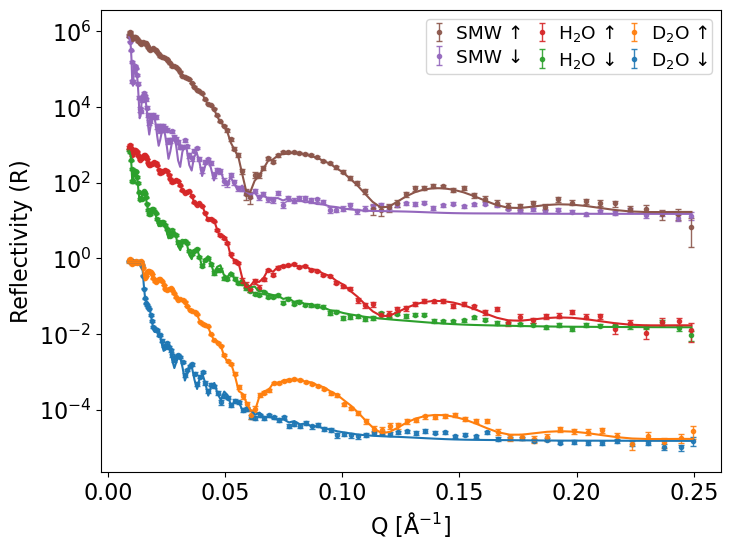

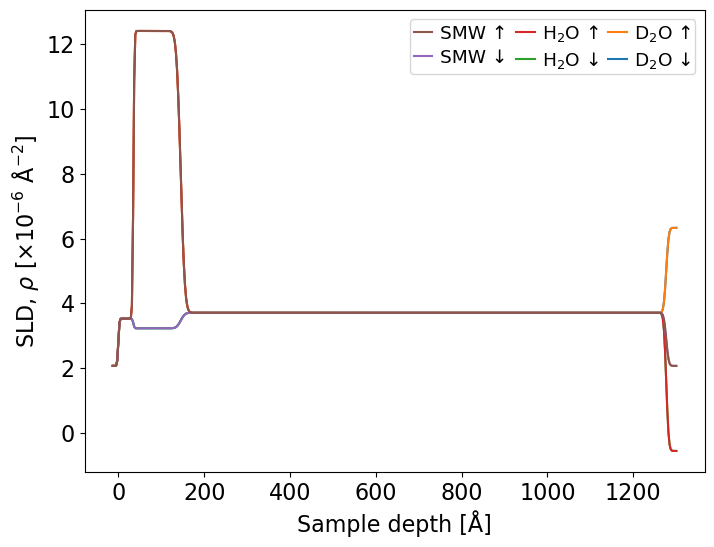

In [9]:
stage1_cfg = StagePlotConfig(
    objective_group=global_objective,
    structures=[
        si_D2O_d_structure,
        si_D2O_u_structure,
        si_H2O_d_structure,
        si_H2O_u_structure,
        si_mw_d_structure,
        si_mw_u_structure,
    ],
    refl_labels=[
        r'$\mathrm{D}_{\mathrm{2}}$O ↓',
        r'$\mathrm{D}_{\mathrm{2}}$O ↑',
        r'$\mathrm{H}_{\mathrm{2}}$O ↓',
        r'$\mathrm{H}_{\mathrm{2}}$O ↑',
        'SMW ↓',
        'SMW ↑',
    ],
    sld_labels=[
        r'$\mathrm{D}_{\mathrm{2}}$O ↓',
        r'$\mathrm{D}_{\mathrm{2}}$O ↑',
        r'$\mathrm{H}_{\mathrm{2}}$O ↓',
        r'$\mathrm{H}_{\mathrm{2}}$O ↑',
        'SMW ↓',
        'SMW ↑',
    ],
    colors=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"],
    shifts=[1, 1, 1e3, 1e3, 1e6, 1e6],
    refl_save_path=f"figures/Refl_fit_{MRL}_MRL_{Capping}_cap.svg",
    sld_save_path=f"figures/SLD_{MRL}_MRL_{Capping}_cap.svg",
    corner_save_path=f"figures/Corner_MCMC_{MRL}_MRL_{Capping}_cap.svg",
    legend_ncol=3,
    corner_left=0.15,
    corner_bottom=0.15,
)

stage1_artifacts = run_fitting_stage_plots(
    cfg=stage1_cfg,
    fitter=fitter,
    do_sampling=DO_SAMPLING,
    save_figs=SAVE_FIGS,
)

## Stage 1 summary

In [ ]:
if DO_SAMPLING:
  # Fitted parameters with updated uncertainties past MCMC sampling
  print("Fitted Parameters")
  print(global_objective.varying_parameters())

### Now lets add the lipid layer, fix the substrate parameters and fit the additional data

In [ ]:
data_filenames_lipid = [
                 'Sample1_Sub_lipid_p30_D2O_post_TRIS_rinse_no_bkg_subtraction_d',
                 'Sample1_Sub_lipid_p30_D2O_post_TRIS_rinse_no_bkg_subtraction_u',
                 ]

In [ ]:
# Additional required parameters for adsorbed soft matter onto previous substrate assembly

# Entire stack with lipid bilayer model:
# Si | Native SiO2 | Fe MRL | SiO2 capping | inner D2O layer | lipid headgroup | tailgroup | headgroup | D2O solvent

water_thick = refnx.analysis.Parameter(6.1,    'Inner D2O layer Thick.', (3,15))

lip_heads_TRIS_thick      = refnx.analysis.Parameter(14.9,    'Lipid TRIS heads Thick.', (6,15))
lip_heads_TRIS_sld        = refnx.analysis.Parameter(1.24,     'Lipid TRIS heads SLD', (1.2,2))

lip_heads_solv_frac         = refnx.analysis.Parameter(0.65,     'Lipid TRIS heads SLD solvf', (0.3,0.7))
heads_TRIS_sld = lip_heads_solv_frac * d2o_sld
heads_TRIS_sld += (1 - lip_heads_solv_frac) * lip_heads_TRIS_sld

lip_tails_TRIS_thick        = refnx.analysis.Parameter(30.3,    'Lipid TRIS tails Thick.', (25,40))
lip_tails_TRIS_sld          = refnx.analysis.Parameter(-0.16,     'Lipid TRIS tails SLD', (-0.5,3))

lip_tails_solv_frac         = refnx.analysis.Parameter(0.11,     'Lipid TRIS tails SLD solvf', (0,0.2))
tails_TRIS_sld = lip_tails_solv_frac * d2o_sld
tails_TRIS_sld += (1 - lip_tails_solv_frac) * lip_tails_TRIS_sld

lip_TRIS_rough        = refnx.analysis.Parameter(3,     'Lipid TRIS Rough.', (3,6))

# Make the slabs
water = refnx.reflect.Slab(water_thick, d2o_sld, lip_TRIS_rough, vfsolv=0.0)
lip_heads_TRIS_layer = refnx.reflect.Slab(lip_heads_TRIS_thick, heads_TRIS_sld, lip_TRIS_rough, vfsolv=0.0)
lip_tails_TRIS_layer = refnx.reflect.Slab(lip_tails_TRIS_thick, tails_TRIS_sld, lip_TRIS_rough, vfsolv=0.0)

In [ ]:
# Fix all substrate parameters we just fitted
for param in params:
    param.vary=False

# Define the lipid parameters and allow them to vary
params = [
        lip_heads_TRIS_thick,
        lip_heads_solv_frac,
        lip_tails_TRIS_thick,
        lip_tails_solv_frac,
        water_thick
        ]

for param in params:
    param.vary=True

In [ ]:
# # Define new structures
si_lipid_TRIS_D2O_d_structure = substrate | sio2_nat_layer | MRL_d | cap_layer | water | lip_heads_TRIS_layer | lip_tails_TRIS_layer | lip_heads_TRIS_layer | d2o(0, rough=lip_TRIS_rough)
si_lipid_TRIS_D2O_u_structure = substrate | sio2_nat_layer | MRL_u | cap_layer | water | lip_heads_TRIS_layer | lip_tails_TRIS_layer | lip_heads_TRIS_layer | d2o(0, rough=lip_TRIS_rough)
structures_sample = [
                si_lipid_TRIS_D2O_d_structure,
                si_lipid_TRIS_D2O_u_structure
              ]
objectives_sample = []


for i, structure in enumerate(structures_sample):
    # Define the model.
    model = refnx.reflect.ReflectModel(structure,
                                      scale=scales[i],
                                      bkg=bkgs[i],
                                      dq=dq)
    # Load the measured data.
    filename = '{}.dat'.format(data_filenames_lipid[i])
    file_path = os.path.join(data_path, filename)
    data = refnx.dataset.ReflectDataset(file_path)

    # Combine model and data into an objective that can be fitted.
    objectives_sample.append(refnx.analysis.Objective(model, data))

In [ ]:
sample_objective = GlobalObjective(list(objectives_sample))
fitter = CurveFitter(sample_objective)

In [ ]:
result = fitter.fit('differential_evolution')

In [ ]:
print(f"Fitted Parameters \n {sample_objective.varying_parameters()}")

### Plot and save reflectivity, SLD and optional corner plots (SUB+lipids in D2O fit)

In [ ]:
stage2_cfg = StagePlotConfig(
    objective_group=sample_objective,
    structures=[
        si_lipid_TRIS_D2O_d_structure,
        si_lipid_TRIS_D2O_u_structure,
    ],
    refl_labels=[
        r'Lipids TRIS $\mathrm{D}_{\mathrm{2}}$O ↓',
        r'Lipids TRIS $\mathrm{D}_{\mathrm{2}}$O ↑',
    ],
    sld_labels=[
        r'Lipids TRIS $\mathrm{D}_{\mathrm{2}}$O ↓',
        r'Lipids TRIS $\mathrm{D}_{\mathrm{2}}$O ↑',
    ],
    colors=["#e377c2", "#7f7f7f"],
    shifts=[1, 1],
    refl_save_path=f"figures/Refl_lipids_D2O_fit_{MRL}_MRL_{Capping}_cap.svg",
    sld_save_path=f"figures/SLD_lipids_D2O_{MRL}_MRL_{Capping}_cap.svg",
    corner_save_path=f"figures/Corner_MCMC_lipids_D2O_{MRL}_MRL_{Capping}_cap.svg",
    legend_ncol=None,
    corner_left=0.13,
    corner_bottom=0.13,
)

stage2_artifacts = run_fitting_stage_plots(
    cfg=stage2_cfg,
    fitter=fitter,
    do_sampling=DO_SAMPLING,
    save_figs=SAVE_FIGS,
)

## Stage 2 summary

In [ ]:
if DO_SAMPLING:
  print("Fitted Parameters")
  print(sample_objective.varying_parameters())

In [ ]:
## Save fitted parameters for subsequent FI runs
## Do not rerun after running the FI optimisation below.

fi_params = [MRL_thick, cap_thick, MRL_sld, MRL_mag]
baseline_fit = snapshot_params(fi_params)

## Fisher optimisation

In [ ]:
if DO_FISHER == True:
    restore_params(baseline_fit)

    # include every Parameter that affects the rebuilt structures
    model_params = [MRL_thick, cap_thick, MRL_sld, MRL_mag]

    print("Saved baseline after fitting:")
    for p in model_params:
        print(p.name, baseline_fit[p])
        # print(p.name, baseline_vals[p])

    def make_structures():
        d2o = refnx.reflect.SLD(d2o_sld)
        substrate = refnx.reflect.SLD(si_sld)
        sio2_nat_layer = refnx.reflect.Slab(sio2_native_thick, sio2_native_sld, 2, vfsolv=0.0)

        MRL_d = refnx.reflect.Slab(MRL_thick, MRL_sld - MRL_mag, 2)
        MRL_u = refnx.reflect.Slab(MRL_thick, MRL_sld + MRL_mag, 2)
        cap_layer = refnx.reflect.Slab(cap_thick, cap_sld, 2, vfsolv=0.0)

        water = refnx.reflect.Slab(water_thick, d2o_sld, lip_TRIS_rough, vfsolv=0.0)
        heads = refnx.reflect.Slab(lip_heads_TRIS_thick, heads_TRIS_sld, lip_TRIS_rough, vfsolv=0.0)
        tails = refnx.reflect.Slab(lip_tails_TRIS_thick, tails_TRIS_sld, lip_TRIS_rough, vfsolv=0.0)

        down = substrate | sio2_nat_layer | MRL_d | cap_layer | water | heads | tails | heads | d2o(0, rough=lip_TRIS_rough)
        up   = substrate | sio2_nat_layer | MRL_u | cap_layer | water | heads | tails | heads | d2o(0, rough=lip_TRIS_rough)

        return [down, up]
    
    def make_ctx(mrl_display_name):
        return FisherContext(
            MRL=MRL,
            Capping=Capping,
            out_dir="figures",
            save_figs=SAVE_FIGS,
            baseline_vals_by_name=baseline_by_name(baseline_fit),
            mrl_display_name=mrl_display_name,
            mrl_thick_name=MRL_thick.name,
            cap_thick_name=cap_thick.name,
            mrl_sld_name=MRL_sld.name,
            mrl_mag_name=MRL_mag.name,
    )

### FI case 1: optimise Fe MRL and SiO2 capping thicknesses only

In [ ]:
if DO_FISHER == True:
    ctx = make_ctx("Fe")
    
    structures_sample = reset_to_fitted_baseline(baseline_fit, model_params, make_structures)
    optimisable_sample = Sample(structures_sample)

    MRL_thick.optimize = True
    MRL_thick.bounds = (0, 300)

    cap_thick.optimize = True
    cap_thick.bounds = (0, 1400)

    MRL_sld.optimize = False
    MRL_mag.optimize = False

    angle_times = [(0.7, 100, 25), (2.0, 100, 75)]
    optimise_parameters(optimisable_sample, angle_times, "POLREF")
    process_hogben_figures(ctx, filename_stem="Fisher_case1")

### FI case 2: optimise trial MRL thickness + nSLD + mSLD and SiO2 capping thickness

In [ ]:
if DO_FISHER == True:
    ctx = make_ctx("Trial")
    
    structures_sample = reset_to_fitted_baseline(baseline_fit, model_params, make_structures)
    optimisable_sample = Sample(structures_sample)

    MRL_thick.optimize = True
    MRL_thick.bounds = (0, 300)

    cap_thick.optimize = True
    cap_thick.bounds = (0, 1400)

    MRL_sld.optimize = True
    MRL_sld.bounds = (-1, 7)

    MRL_mag.optimize = True
    MRL_mag.bounds = (-0.1, 6)

    angle_times = [(0.7, 100, 25), (2.0, 100, 75)]
    optimise_parameters(optimisable_sample, angle_times, "POLREF")
    process_hogben_figures(ctx, filename_stem="Fisher_case2")